In [ ]:
## Data generated by sergeev et al. (2025)

In [ ]:
## Imports
import iris
import aeolus
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import iris.plot as iplt
import iris.quickplot as qplt
import aeolus
import aeolus.calc

In [16]:
# Import first data set: pressure = 1 bar
m09 = iris.load('/data/cluster4/jj22956/thunderstruck_files/thunderstruck-hab1_1bar-m09.nc?download=1')
m09

[<iris 'Cube' of Number_of_lightning_flashes / (1) (latitude: 1920; longitude: 2560)>,
<iris 'Cube' of cloud_area_fraction_assuming_maximum_random_overlap / (1) (latitude: 1920; longitude: 2560)>,
<iris 'Cube' of graupel_mixing_ratio / (kg kg-1) (model_level_number: 51; latitude: 1920; longitude: 2560)>,
<iris 'Cube' of graupel_water_path / (kg m-2) (latitude: 1920; longitude: 2560)>,
<iris 'Cube' of cloud_volume_fraction_in_atmosphere_layer / (1) (model_level_number: 50; latitude: 1920; longitude: 2560)>,
<iris 'Cube' of total_ice_water_path / (kg m-2) (latitude: 1920; longitude: 2560)>,
<iris 'Cube' of air_temperature / (K) (model_level_number: 50; latitude: 1920; longitude: 2560)>,
<iris 'Cube' of cloud_ice_mixing_ratio / (kg kg-1) (model_level_number: 51; latitude: 1920; longitude: 2560)>,
<iris 'Cube' of cloud_liquid_water_mixing_ratio / (kg kg-1) (model_level_number: 51; latitude: 1920; longitude: 2560)>,
<iris 'Cube' of stratiform_rainfall_flux / (kg m-2 s-1) (latitude: 1920; longitude: 2560)>,
<iris 'Cube' of stratiform_snowfall_flux / (kg m-2 s-1) (latitude: 1920; longitude: 2560)>,
<iris 'Cube' of surface_temperature / (K) (latitude: 1920; longitude: 2560)>]

In [ ]:
## Functions for cube loading

def full_air_temperature(cube):
    air_temp = cube.extract_cube('m01s16i004')
    air_temp_mean = aeolus.calc.stats.vertical_mean(air_temp)
    return air_temp_mean

def full_LFR(cube):
    LFR = cube.extract_cube('m01s21i104')
    return LFR

In [21]:
onebar_full_temps = full_air_temperature(m09)
onebar_full_temps


/home/jj22956/.local/lib/python3.12/site-packages/iris/coords.py:2258: IrisVagueMetadataWarning: Cannot check if coordinate is contiguous: Invalid operation for 'model_level_number', with 0 bound(s). Contiguous bounds are only defined for 1D coordinates with 2 bounds. Metadata may not be fully descriptive for 'model_level_number'. Ignoring bounds.
  warnings.warn(
/home/jj22956/.local/lib/python3.12/site-packages/iris/common/mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


<iris 'Cube' of vertical_mean_of_air_temperature / (K) (latitude: 1920; longitude: 2560)>

In [ ]:
## Creating contoured global air temperature map

air_tempmean = aeolus.calc.stats.vertical_mean(air_temp)

# Add contour and put in variable called contour
contour = qplt.contour(air_tempmean, 25)

# Add coastlines to map created by contour
# plt.gca().coastlines()

# Add air temp contour labels
plt.clabel(contour, inline=False)
plt.savefig('figures/air_temp_global_contours')
plt.show()

AttributeError: 'CubeList' object has no attribute 'coord_dims'

In [ ]:
# Plotting a filled contour plot
qplt.contourf(air_temp[0], 25)


plt.savefig('figures/air_temp_global_filled_contours')
plt.show()

ValueError: Cube must be 2-dimensional. Got 3 dimensions.

C:\Users\LilyO\OneDrive - University of Bristol\Documents\Lily\coding\envs\Storm\Lib\site-packages\iris\common\mixin.py:206: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


0: total_ice_water_path / (kg m-2)     (latitude: 1920; longitude: 2560)


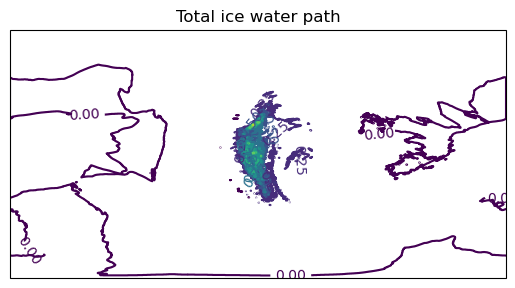

In [ ]:
# Extract total ice water path
ice_path = m09.extract('total_ice_water_path')
print(ice_path) # Check it's showing correctly

ice_path = ice_path[0]
# Add contour and put in variable called contour
contour = qplt.contour(ice_path)


# Add air temp contour labels
plt.clabel(contour)
plt.savefig('figures/ice_water_path_contours')
plt.show()

[-179.9296875 -179.7890625 -179.6484375 ...  179.6484375  179.7890625
  179.9296875]
[-89.953125 -89.859375 -89.765625 ...  89.765625  89.859375  89.953125]
(1920, 2560)
(1920, 2560)


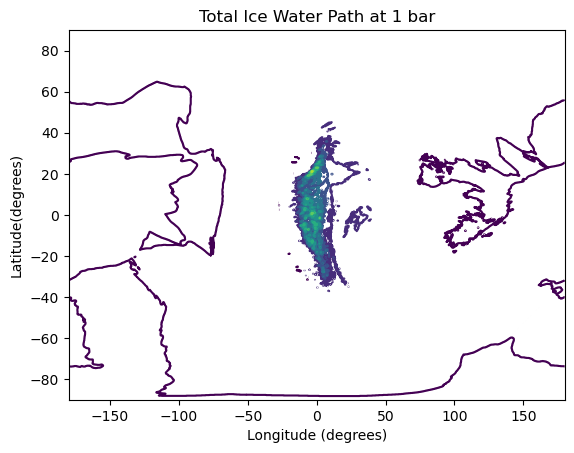

In [ ]:
## Correcting the coordinates of the total ice water path to plot on axis

import aeolus.coord as ac
corrected_ice = ac.roll_cube_pm180(ice_path, add_shift=0)

x = corrected_ice.coord('longitude').points
y = corrected_ice.coord('latitude').points
print(x)
print(y)

print(corrected_ice.shape)
# Extract data values (2D array)
data = corrected_ice.data
print(data.shape)


# Create a meshgrid for plotting
X, Y = np.meshgrid(x, y)

# Now plot using matplotlib
plt.contour(X, Y, data)
plt.xlabel('Longitude (degrees)')
plt.ylabel('Latitude(degrees)')
plt.title("Total Ice Water Path at 1 bar")
plt.savefig('figures/mesh_grid_ice_water_1_bar.png')
plt.show()

In [ ]:
## Extract LFR

LFR = m09.extract('Number_of_lightning_flashes')
LFR = LFR[0]
LFR_data = LFR.data
LFR_data.shape

In [10]:
LFR_flat = LFR_data.flatten()

In [11]:
TIWP_data = ice_path.data
TIWP_data.shape

(1920, 2560)

In [12]:
TIWP_flat = TIWP_data.flatten()


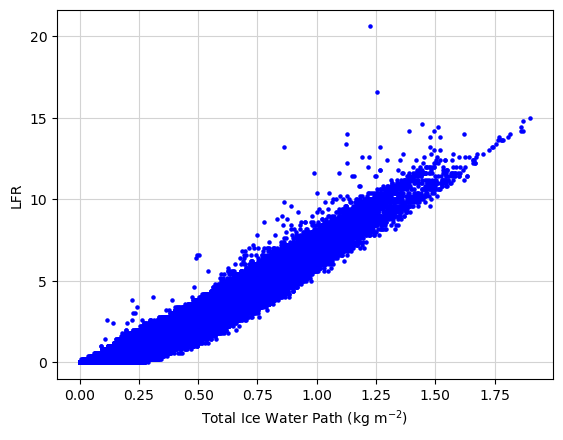

In [ ]:
## Plotting LFR as a function of cloud ice content (both vertically integrated)

plt.scatter(TIWP_flat, LFR_flat, s = 5, facecolor = 'blue', zorder = 3)
plt.xlabel(r"Total Ice Water Path (kg m$^{-2}$)")
plt.ylabel("LFR")
plt.grid(True, color = 'lightgrey', zorder = 0)
plt.savefig("figures/LFR-TIWP.png")
plt.show()

In [ ]:
## Finding relationship between LFR and air temperature

air_temp_data = air_temp.data
air_temp_data.shape
air_temp_flat = air_temp_data.flatten()

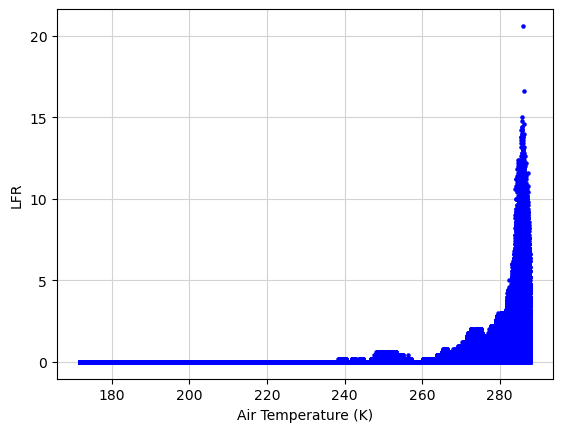

In [ ]:
## Plotting LFR dependence on air temperature

plt.scatter(air_temp_flat, LFR_flat, s = 5, facecolor = 'blue', zorder = 3)
plt.xlabel(r"Air Temperature (K)")
plt.ylabel("LFR")
plt.grid(True, color = 'lightgrey', zorder = 0)
plt.savefig("figures/LFR-temp.png")
plt.show()

In [ ]:
## Extracting stratiform rainfall flux

rainfall = m09.extract('stratiform_rainfall_flux')
rainfall = rainfall[0]
rainfall_data = rainfall.data
rainfall_data.shape
rainfall_flat = rainfall_data.flatten()

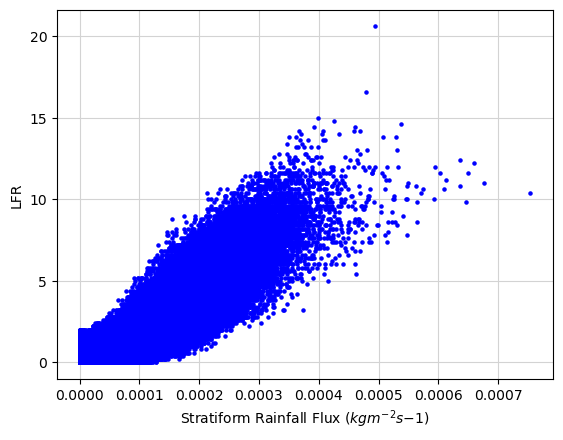

In [ ]:
## Plotting dependency of LFR on stratiform rainfall flux

plt.scatter(rainfall_flat, LFR_flat, s = 5, facecolor = 'blue', zorder = 3)
plt.xlabel(r"Stratiform Rainfall Flux ($kg m^{-2} s{-1}$)")
plt.ylabel("LFR")
plt.grid(True, color = 'lightgrey', zorder = 0)
plt.savefig("figures/LFR-rainfall.png")
plt.show()